# Семинар 1. Линейная регрессия

# Вопрос 1:
Мы разбиваем данные на выборки для полного обучения, чтобы модель могла предсказывать таргет, если видит данные  впервые
Тренировочная выборка - для подбора основных параметров весов
Валидационная выборка - для проверки работы на новых данных и возможного изменения гиперпараметров
Тестовая выборка - финальная проверка на новых данных
# Вопрос 2:
Графики показывают насколько наша модель обучилась - чем ниже линии, тем меньше ошибка - тем лучше она будет предсказывать таргет
# Вопрос 3: 
Недообученная - линии высоко и близко
Обученная - линии стремятся вниз и близко
Переобученная - линия тренировочной стремится вниз , в то время как линия валидационной выборки так не стемится + большой разрывВопрос 
# Вопрос 4:
Получившийся RMSE говорит, что модель в среднем ошибатеся на +- 5 минут




#### Шаг 1. Загрузка датасета и вывод на экран

In [30]:
import pandas as pd

data = pd.read_csv("delivery_dataset.csv")
data.head(2)

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [31]:


features = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)",
]

target = "Время доставки (в минутах)"

train = data.iloc[:300].copy()
val = data.iloc[300:400].copy()
test = data.iloc[400:500].copy()

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]
X_test, y_test = test[features], test[target]




#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [32]:
#skip!!!!

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [33]:
from sklearn.linear_model import Ridge


model = Ridge(alpha=0.0, solver='sparse_cg')

model.fit(X_train, y_train)



,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.0
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'sparse_cg'
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 's

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

In [ ]:
import numpy as np

X_train_np = X_train.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)
X_val_np   = X_val.to_numpy(dtype=float)
y_val_np   = y_val.to_numpy(dtype=float)

mu    = X_train_np.mean(axis=0)
sigma = X_train_np.std(axis=0)

X_train_s = (X_train_np - mu) / sigma
X_val_s   = (X_val_np   - mu) / sigma


n_samples, n_features = X_train_s.shape
alpha    = 1.0     
lr       = 0.01    
n_epochs = 300

w = np.zeros(n_features)
b = 0.0


hist = {
    "epoch":     [],
    "sse_train": [], "mse_train": [], "rmse_train": [],
    "sse_val":   [], "mse_val":   [], "rmse_val":   [],
}


for epoch in range(1, n_epochs + 1):
    y_pred_train = X_train_s @ w + b
    y_pred_val   = X_val_s   @ w + b

    err_train = y_pred_train - y_train_np
    err_val   = y_pred_val   - y_val_np

    sse_train  = np.sum(err_train ** 2)
    mse_train  = sse_train / n_samples
    rmse_train = np.sqrt(mse_train)

    sse_val  = np.sum(err_val ** 2)
    mse_val  = sse_val / len(y_val_np)
    rmse_val = np.sqrt(mse_val)

    hist["epoch"].append(epoch)
    hist["sse_train"].append(sse_train);  hist["mse_train"].append(mse_train);  hist["rmse_train"].append(rmse_train)
    hist["sse_val"].append(sse_val);      hist["mse_val"].append(mse_val);      hist["rmse_val"].append(rmse_val)

    grad_w = (2 / n_samples) * (X_train_s.T @ err_train) + 2 * alpha * w
    grad_b = (2 / n_samples) * np.sum(err_train)

    w -= lr * grad_w
    b -= lr * grad_b

hist_df = pd.DataFrame(hist)

print("Финальные веса:", np.round(w, 4))
print("Финальный bias:", round(b, 4))


Финальные веса: [12.7426  1.4679  2.1859 -0.454   1.2302]
Финальный bias: 42.7294


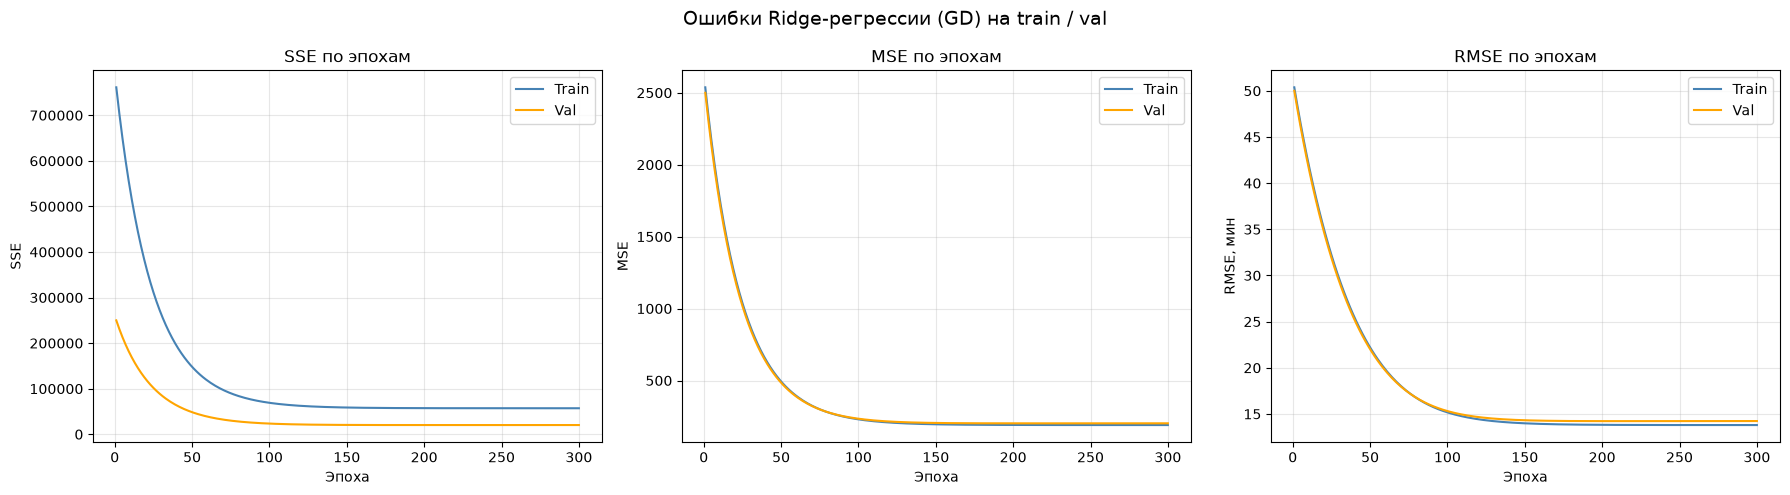

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- SSE ---
axes[0].plot(hist_df["epoch"], hist_df["sse_train"], label="Train", color="steelblue")
axes[0].plot(hist_df["epoch"], hist_df["sse_val"],   label="Val",   color="orange")
axes[0].set_title("SSE по эпохам")
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("SSE")
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- MSE ---
axes[1].plot(hist_df["epoch"], hist_df["mse_train"], label="Train", color="steelblue")
axes[1].plot(hist_df["epoch"], hist_df["mse_val"],   label="Val",   color="orange")
axes[1].set_title("MSE по эпохам")
axes[1].set_xlabel("Эпоха"); axes[1].set_ylabel("MSE")
axes[1].legend(); axes[1].grid(alpha=0.3)

# --- RMSE ---
axes[2].plot(hist_df["epoch"], hist_df["rmse_train"], label="Train", color="steelblue")
axes[2].plot(hist_df["epoch"], hist_df["rmse_val"],   label="Val",   color="orange")
axes[2].set_title("RMSE по эпохам")
axes[2].set_xlabel("Эпоха"); axes[2].set_ylabel("RMSE, мин")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Ошибки Ridge-регрессии (GD) на train / val", fontsize=14)
plt.tight_layout()
plt.show()

#### Шаг 6. Применение модели на тестовой выборке + RMSE

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred_test = model.predict(X_test)


mse  = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_test)



print(f"RMSE = {rmse:8.2f} мин")


Метрики на тестовой выборке
RMSE =     4.83 мин
